In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [101]:
data = pd.read_csv('heart.csv')
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [102]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [103]:
data.shape

(918, 12)

In [104]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [105]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [106]:
data.drop_duplicates().sum()
data.drop_duplicates(inplace=True)
data.shape

(918, 12)

<Axes: xlabel='HeartDisease'>

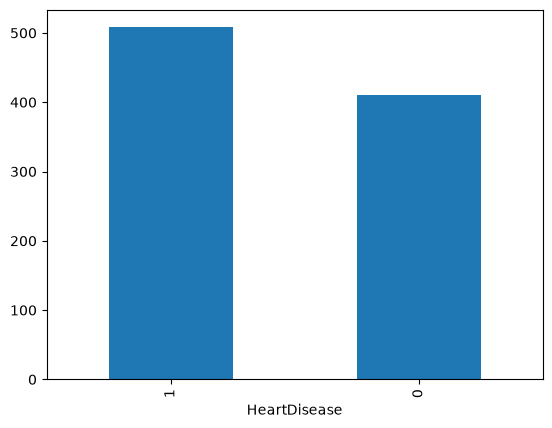

In [107]:
data['HeartDisease'].value_counts().plot(kind='bar')

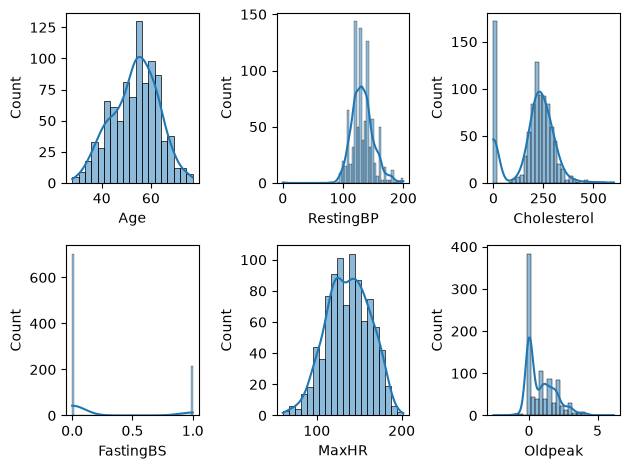

In [108]:
def plotting(var,num):
    plt.subplot(2,3,num)
    sns.histplot(data[var],kde=True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('FastingBS',4)
plotting('MaxHR',5)
plotting('Oldpeak',6)

plt.tight_layout()



In [109]:
data['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [110]:
ch_mean = data.loc[data['Cholesterol']!=0,'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [111]:
### replacing cholestrol 0 with mean becuz cholestroal 0 means impossible
data['Cholesterol'] = data['Cholesterol'].replace(0,ch_mean)
data['Cholesterol'] = data['Cholesterol'].round(2)
data['Cholesterol'].value_counts

<bound method IndexOpsMixin.value_counts of 0      289.0
1      180.0
2      283.0
3      214.0
4      195.0
       ...  
913    264.0
914    193.0
915    131.0
916    236.0
917    175.0
Name: Cholesterol, Length: 918, dtype: float64>

In [112]:
RestBP_mean = data.loc[data['RestingBP']!=0,'RestingBP'].mean()

### replacing RestingBP 0 with mean becuz RESTINGBP 0 means impossible
data['RestingBP'] = data['RestingBP'].replace(0,ch_mean)
data['RestingBP'] = data['RestingBP'].round(2)
data['RestingBP'].value_counts


<bound method IndexOpsMixin.value_counts of 0      140.0
1      160.0
2      130.0
3      138.0
4      150.0
       ...  
913    110.0
914    144.0
915    130.0
916    130.0
917    138.0
Name: RestingBP, Length: 918, dtype: float64>

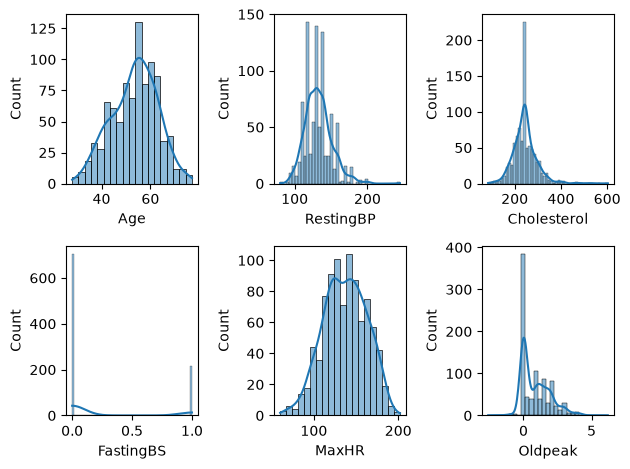

In [113]:
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('FastingBS',4)
plotting('MaxHR',5)
plotting('Oldpeak',6)
plt.tight_layout()

In [114]:
import sheryanalysis as sh
sh.analyze(data)


🔍 Basic Analysis Report
------------------------------------------------------------
📏 Shape: (918, 12)
🧱 Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

✅ No null values found

🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


{'shape': (918, 12),
 'columns': ['Age',
  'Sex',
  'ChestPainType',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'RestingECG',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ST_Slope',
  'HeartDisease'],
 'dtypes': {'Age': dtype('int64'),
  'Sex': <StringDtype(na_value=nan)>,
  'ChestPainType': <StringDtype(na_value=nan)>,
  'RestingBP': dtype('float64'),
  'Cholesterol': dtype('float64'),
  'FastingBS': dtype('int64'),
  'RestingECG': <StringDtype(na_value=nan)>,
  'MaxHR': dtype('int64'),
  'ExerciseAngina': <StringDtype(na_value=nan)>,
  'Oldpeak': dtype('float64'),
  'ST_Slope': <StringDtype(na_value=nan)>,
  'HeartDisease': dtype('int64')},
 'null_counts': {'Age': 0,
  'Sex': 0,
  'ChestPainType': 0,
  'RestingBP': 0,
  'Cholesterol': 0,
  'FastingBS': 0,
  'RestingECG': 0,
  'MaxHR': 0,
  'ExerciseAngina': 0,
  'Oldpeak': 0,
  'ST_Slope': 0,
  'HeartDisease': 0},
 'total_rows': 918,
 'column_types': {'categorical': ['Sex',
   'ChestPainType',
   'FastingBS',
   'RestingECG',

<Axes: xlabel='Sex', ylabel='count'>

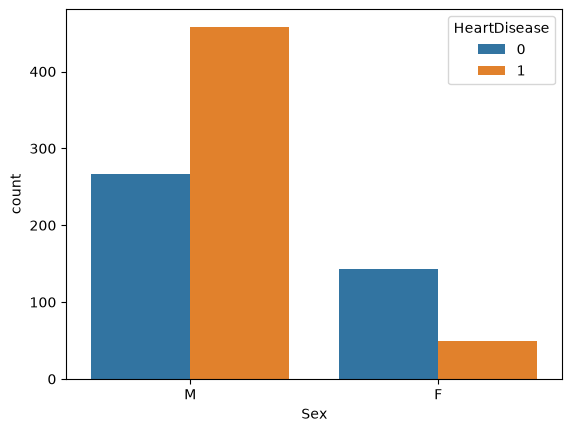

In [115]:
sns.countplot(x=data['Sex'],hue=data['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

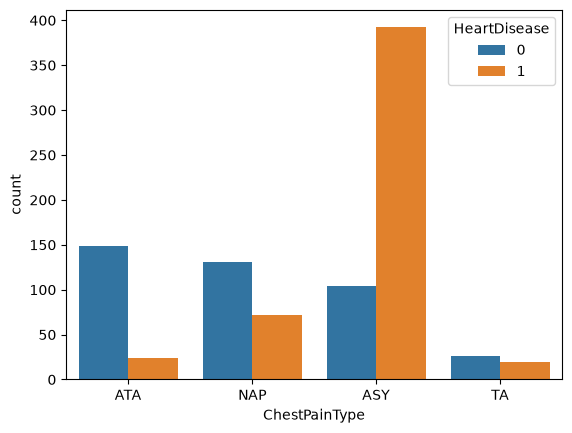

In [116]:
sns.countplot(x=data['ChestPainType'],hue=data['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

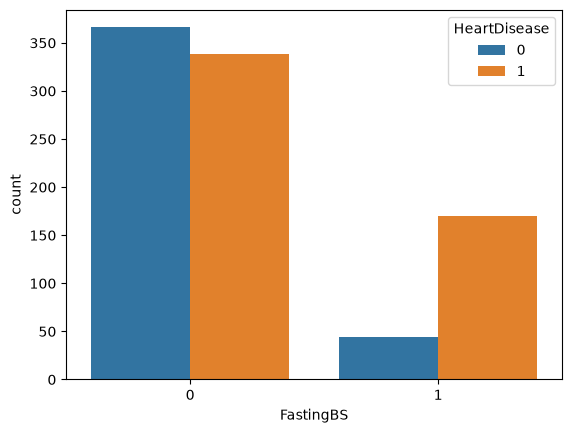

In [117]:
sns.countplot(x=data['FastingBS'],hue=data['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

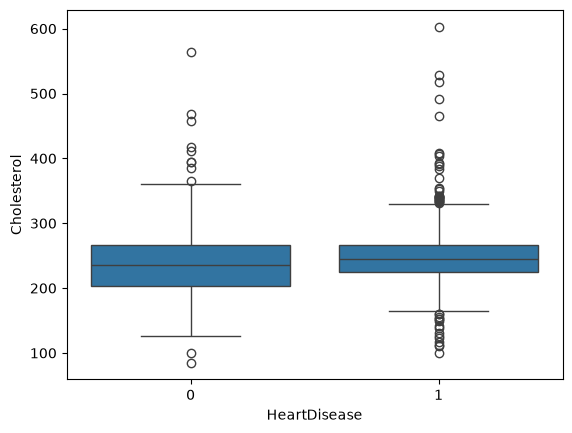

In [118]:
sns.boxplot(x='HeartDisease',y='Cholesterol',data=data)

<Axes: xlabel='HeartDisease', ylabel='Age'>

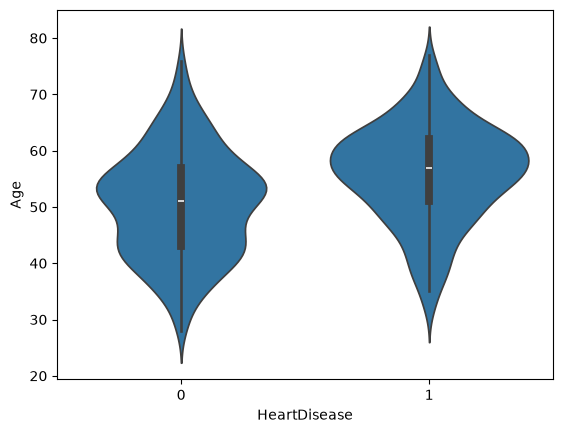

In [119]:
sns.violinplot(x='HeartDisease',y='Age',data=data)

<Axes: >

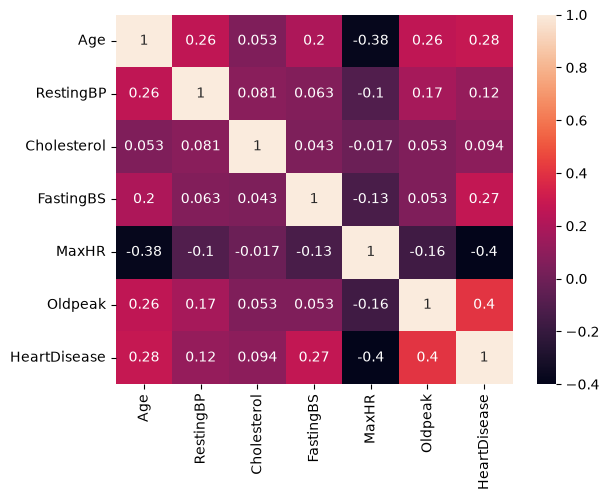

In [120]:
sns.heatmap(data.corr(numeric_only=True),annot=True)

In [121]:
### data preprocessing and cleaning

df = pd.get_dummies(data,drop_first=True)
df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [122]:
df.astype(int)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [123]:
from sklearn.preprocessing import StandardScaler
numeric_cols = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.399696,0.832513,0,1.382928,-0.832432,0,True,True,False,False,True,False,False,False,True
1,-0.478484,1.489232,-1.212938,0,0.754157,0.105664,1,False,False,True,False,True,False,False,True,False
2,-1.751359,-0.145072,0.719919,0,-1.525138,-0.832432,0,True,True,False,False,False,True,False,False,True
3,-0.584556,0.290742,-0.574908,0,-1.132156,0.574711,1,False,False,False,False,True,False,True,True,False
4,0.051881,0.944464,-0.931454,0,-0.581981,-0.832432,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.234608,0.363372,0,-0.188999,0.293283,1,True,False,False,True,True,False,False,True,False
914,1.536902,0.617603,-0.968986,1,0.164684,2.357094,1,True,False,False,False,True,False,False,True,False
915,0.370100,-0.145072,-2.132453,0,-0.857069,0.293283,1,True,False,False,False,True,False,True,True,False
916,0.370100,-0.145072,-0.162065,0,1.461525,-0.832432,1,False,True,False,False,False,False,False,True,False


In [124]:
print(df[numeric_cols].dtypes)
print(df[numeric_cols].head())

Age            float64
RestingBP      float64
Cholesterol    float64
MaxHR          float64
Oldpeak        float64
dtype: object
        Age  RestingBP  Cholesterol     MaxHR   Oldpeak
0 -1.433140   0.399696     0.832513  1.382928 -0.832432
1 -0.478484   1.489232    -1.212938  0.754157  0.105664
2 -1.751359  -0.145072     0.719919 -1.525138 -0.832432
3 -0.584556   0.290742    -0.574908 -1.132156  0.574711
4  0.051881   0.944464    -0.931454 -0.581981 -0.832432


In [125]:
df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.399696,0.832513,0,1.382928,-0.832432,0,True,True,False,False,True,False,False,False,True
1,-0.478484,1.489232,-1.212938,0,0.754157,0.105664,1,False,False,True,False,True,False,False,True,False
2,-1.751359,-0.145072,0.719919,0,-1.525138,-0.832432,0,True,True,False,False,False,True,False,False,True
3,-0.584556,0.290742,-0.574908,0,-1.132156,0.574711,1,False,False,False,False,True,False,True,True,False
4,0.051881,0.944464,-0.931454,0,-0.581981,-0.832432,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.234608,0.363372,0,-0.188999,0.293283,1,True,False,False,True,True,False,False,True,False
914,1.536902,0.617603,-0.968986,1,0.164684,2.357094,1,True,False,False,False,True,False,False,True,False
915,0.370100,-0.145072,-2.132453,0,-0.857069,0.293283,1,True,False,False,False,True,False,True,True,False
916,0.370100,-0.145072,-0.162065,0,1.461525,-0.832432,1,False,True,False,False,False,False,False,True,False


In [126]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [127]:
x = df.drop('HeartDisease',axis=1)
y = df['HeartDisease']

In [128]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [129]:
#model training in one go
models = {
    "logistic_regression": LogisticRegression(),
    "naive_bayes": GaussianNB(),
    "decision_tree": DecisionTreeClassifier(),
    "svm": SVC(),
    "knn": KNeighborsClassifier()
}

In [ ]:
result = []

for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    result.append({
        'Model':name,
        'Accuracy':round(accuracy,4),
        'F1_Score':round(f1,4)
    })

In [131]:
result

[{'Model': 'logistic_regression', 'Accuracy': 0.8587, 'F1_Score': 0.8829},
 {'Model': 'naive_bayes', 'Accuracy': 0.8587, 'F1_Score': 0.8785},
 {'Model': 'decision_tree', 'Accuracy': 0.788, 'F1_Score': 0.8152},
 {'Model': 'svm', 'Accuracy': 0.8261, 'F1_Score': 0.8609},
 {'Model': 'knn', 'Accuracy': 0.8641, 'F1_Score': 0.8837}]

In [133]:
import joblib
joblib.dump(models['knn'],'knn_heart_prediction.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(x.columns.tolist(),'columns.pkl')

['columns.pkl']